In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
import tensorflow as tf

In [2]:
pd.set_option("display.max_columns", None)
sns.set_theme(style = "darkgrid")
warnings.filterwarnings("ignore")

In [3]:
def seed_everything(seed = 42):
    np.random.seed(seed)
    tf.random.set_seed(seed)

seed_everything()

In [4]:
x = pd.read_csv("../data/cleaned_and_split/x.csv")
x_train = pd.read_csv("../data/cleaned_and_split/x_train.csv")
x_test = pd.read_csv("../data/cleaned_and_split/x_test.csv")
y = pd.read_csv("../data/cleaned_and_split/y.csv")
y_train = pd.read_csv("../data/cleaned_and_split/y_train.csv")
y_test = pd.read_csv("../data/cleaned_and_split/y_test.csv")

In [5]:
x.head()

,Unnamed: 0,x,y,z
0,0,0.04,0.02,1.0
1,1,0.04,0.02,1.0
2,2,0.04,0.02,1.0
3,3,0.04,0.02,1.0
4,4,0.04,0.02,1.0


In [6]:
x_train.head()

,Unnamed: 0,x,y,z
0,9318,0.04,0.03,1.0
1,18896,0.04,0.05,1.0
2,8871,0.04,0.02,1.0
3,18790,0.04,0.04,1.0
4,17362,0.04,0.03,1.0


In [7]:
x_test.head()

,Unnamed: 0,x,y,z
0,10178,-0.14,0.06,0.93
1,8585,0.05,0.02,1.03
2,451,-0.01,0.05,1.12
3,6014,0.04,0.03,1.00
4,15342,0.06,-0.05,1.00


In [8]:
y.head()

,Unnamed: 0,gesture_name
0,0,0
1,1,0
2,2,0
3,3,0
4,4,0


In [9]:
y_train.head()

,Unnamed: 0,gesture_name
0,9318,3
1,18896,6
2,8871,3
3,18790,6
4,17362,6


In [10]:
y_test.head()

,Unnamed: 0,gesture_name
0,10178,3
1,8585,3
2,451,0
3,6014,2
4,15342,5


In [11]:
x.drop(columns = ["Unnamed: 0"], inplace = True)
x_train.drop(columns = ["Unnamed: 0"], inplace = True)
x_test.drop(columns = ["Unnamed: 0"], inplace = True)
y.drop(columns = ["Unnamed: 0"], inplace = True)
y_train.drop(columns = ["Unnamed: 0"], inplace = True)
y_test.drop(columns = ["Unnamed: 0"], inplace = True)

In [12]:
x.head()

,x,y,z
0,0.04,0.02,1.0
1,0.04,0.02,1.0
2,0.04,0.02,1.0
3,0.04,0.02,1.0
4,0.04,0.02,1.0


In [13]:
x_train.head()

,x,y,z
0,0.04,0.03,1.0
1,0.04,0.05,1.0
2,0.04,0.02,1.0
3,0.04,0.04,1.0
4,0.04,0.03,1.0


In [14]:
x_test.head()

,x,y,z
0,-0.14,0.06,0.93
1,0.05,0.02,1.03
2,-0.01,0.05,1.12
3,0.04,0.03,1.00
4,0.06,-0.05,1.00


In [15]:
y.head()

,gesture_name
0,0
1,0
2,0
3,0
4,0


In [16]:
y_train.head()

,gesture_name
0,3
1,6
2,3
3,6
4,6


In [17]:
y_test.head()

,gesture_name
0,3
1,3
2,0
3,2
4,5


In [18]:
x.shape, x_train.shape, x_test.shape, y.shape, y_train.shape, y_test.shape

((18008, 3), (14406, 3), (3602, 3), (18008, 1), (14406, 1), (3602, 1))

In [19]:
# using Sequential API from keras to build a classifier
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [20]:
model = Sequential(
    [
        Dense(64, activation = "relu", input_shape = (3, ), name = "hidden_layer_1"), # hidden layer
        Dense(6, activation = "softmax", name = "output_layer") # output layer
    ]
)

2025-05-07 14:37:07.317907: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2025-05-07 14:37:07.317928: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2025-05-07 14:37:07.317932: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
I0000 00:00:1746608827.317943 22238814 pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
I0000 00:00:1746608827.317961 22238814 pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


In [21]:
model.weights

[<Variable path=sequential/hidden_layer_1/kernel, shape=(3, 64), dtype=float32, value=[[ 0.01395163 -0.08154833  0.13173196  0.270876    0.2727046   0.25779104
    0.12150767  0.22903532  0.23722672 -0.25149348  0.1501939  -0.051934
   -0.046864   -0.07570063 -0.02220482  0.29367667  0.13874364 -0.22821039
    0.22827488  0.25423956 -0.22394046  0.09364358  0.03116098 -0.28748634
   -0.28063783  0.2714877   0.03266072  0.27497518  0.10976502 -0.23982282
   -0.2888161  -0.179759   -0.10932973  0.01945594 -0.10710868  0.05141053
    0.23380727  0.21323347  0.23848099  0.23718327  0.03863099  0.26000166
    0.26502407 -0.22814953  0.15663913  0.04126343 -0.0721595   0.20597297
    0.07050183  0.07180741 -0.25887188 -0.08880229 -0.1326629  -0.27598512
    0.0491322  -0.21756122 -0.29483777 -0.21862258  0.22863293 -0.2550047
   -0.13855022 -0.25290117 -0.16542044 -0.22917259]
  [ 0.15892139  0.08275759 -0.23045398  0.2103656   0.16026974  0.2553352
   -0.10373203  0.0631192   0.2141667  -0.

In [22]:
len(model.weights) # w1, b1, w2, b2

4

In [23]:
for i in model.weights:
    print(i.shape)

(3, 64)
(64,)
(64, 6)
(6,)


In [24]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ hidden_layer_1 (Dense)          │ (None, 64)             │           256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output_layer (Dense)            │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 646 (2.52 KB)

 Trainable params: 646 (2.52 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
# hidden layer: 3 * 64 + 64 = 256
# output layer: 64 * 6 + 6 = 390
# in the output of model.summary() the model shape is calculated for a single sample

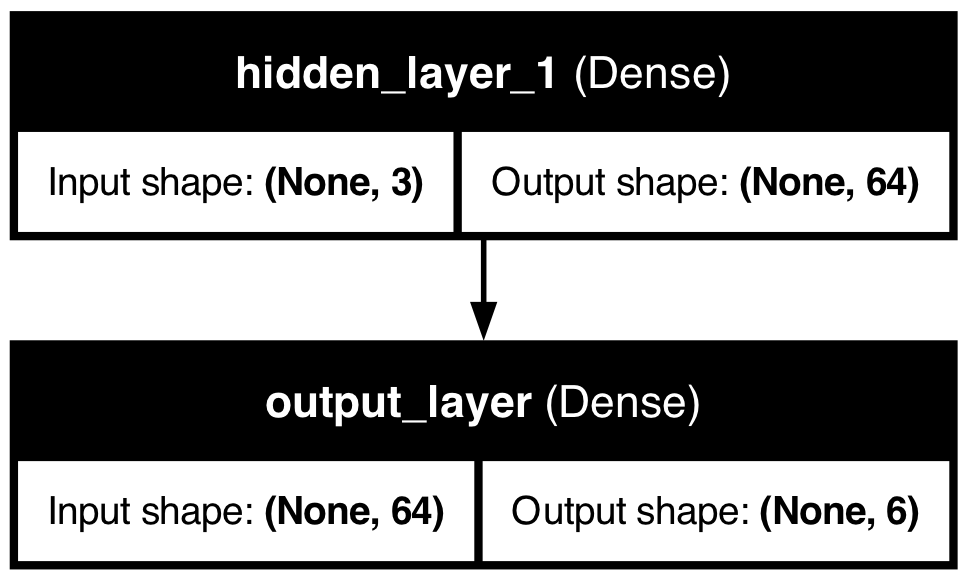

In [26]:
# visualizing the model
from tensorflow.keras.utils import plot_model

plot_model(model, to_file = "model1.png", show_shapes = True, show_layer_names = True)

In [27]:
model.layers

[<Dense name=hidden_layer_1, built=True>,
 <Dense name=output_layer, built=True>]

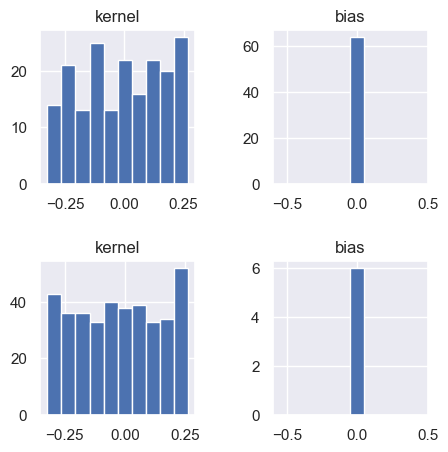

In [28]:
# histograms of initialized weights and biases
fig, axes = plt.subplots(2, 2, figsize = (5, 5))
fig.subplots_adjust(hspace = 0.5, wspace = 0.5)
# extracting weights from the layers
weight_layers = [layer for layer in model.layers]
for i, layer in enumerate(weight_layers):
    for j in [0, 1]:
        axes[i, j].hist(layer.weights[j].numpy().flatten(), align = "left")
        axes[i, j].set_title(layer.weights[j].name)

In [29]:
# compiling the model
model.compile(
    optimizer = tf.keras.optimizers.Adam(learning_rate = 0.001),
    loss = tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics = ["accuracy"]
)

In [30]:
model.loss

<LossFunctionWrapper(<function sparse_categorical_crossentropy at 0x17ca47670>, kwargs={'from_logits': False, 'ignore_class': None})>

In [31]:
model.optimizer

In [32]:
y_train.sample(10)

,gesture_name
5180,6
7855,3
10765,3
12879,5
1418,0
11946,4
290,1
12696,2
13955,2
4292,3


In [33]:
%%time
# model training
model.fit(x_train, y_train, epochs = 500, batch_size = 256, validation_split = 0.1, verbose = 1)

Epoch 1/500


2025-05-07 14:38:34.378488: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.1458 - loss: nan - val_accuracy: 0.0000e+00 - val_loss: nan
Epoch 2/500
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.0000e+00 - loss: nan - val_accuracy: 0.0000e+00 - val_loss: nan
Epoch 3/500
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0000e+00 - loss: nan - val_accuracy: 0.0000e+00 - val_loss: nan
Epoch 4/500
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0000e+00 - loss: nan - val_accuracy: 0.0000e+00 - val_loss: nan
Epoch 5/500
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0000e+00 - loss: nan - val_accuracy: 0.0000e+00 - val_loss: nan
Epoch 6/500
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0000e+00 - loss: nan - val_accuracy: 0.0000e+00 - val_loss: nan
Epoch 7/500
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.0000e+00 - loss: nan - val_accuracy: 0.0000e+00 - val_loss: nan
Epoch 8/500
51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.0000e+00 - loss: nan - val_accuracy: 0.0000e+00